# Entrega: Torneo de Agentes Connect-4
**Fundamentos de Inteligencia Artificial**

Análisis empírico de los tres agentes del reto a partir de los datos del torneo round-robin (150 partidas ya ejecutadas). **No se corre ninguna partida nueva** — toda la evidencia proviene de `versus/roundrobin_results.json`.

| Sección | Contenido |
|---------|----------|
| 1 | Descripción algorítmica de los agentes |
| 2 | Resultados generales del torneo |
| 3 | Curvas de aprendizaje — evolución dentro de cada partida |
| 4 | Curvas de aprendizaje — evolución a través de los 50 juegos |
| 5 | Análisis por color / posición (quién va primero) |
| 6 | Variable numérica: iteraciones MCTS y tasa de victoria |
| 7 | Cuellos de botella y propuestas de mejora |

In [1]:
import os, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

# Locate tournament/ regardless of kernel start location
for _cand in ['.', 'tournament', '../tournament']:
    if os.path.isdir(os.path.join(_cand, 'connect4')):
        TOURNAMENT_DIR = os.path.abspath(_cand)
        break
else:
    raise RuntimeError('Cannot locate tournament/ — run from Connect-4/ or tournament/')

os.chdir(TOURNAMENT_DIR)

with open('versus/roundrobin_results.json', encoding='utf-8') as f:
    data = json.load(f)

AGENTS   = ['Titan', 'Hydra', 'Kronos']
COLORS   = {'Titan': '#e74c3c', 'Hydra': '#3498db', 'Kronos': '#2ecc71'}
N_GAMES  = 50
os.makedirs('versus', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

# Index matchups for easy access
MATCHUPS = {}  # (pa, pb) -> matchup dict
for m in data['matchups']:
    MATCHUPS[(m['player_a'], m['player_b'])] = m

def get_matchup(a, b):
    return MATCHUPS.get((a, b)) or MATCHUPS.get((b, a))

print(f'JSON cargado: {sum(len(m["games"]) for m in data["matchups"])} partidas en {len(data["matchups"])} emparejamientos')

JSON cargado: 150 partidas en 3 emparejamientos


---
## 1. Descripción Algorítmica de los Agentes

### Titan (Grupo A) — Negamax Alpha-Beta + Tabla de Transposición

Titan aplica la ecuación de optimalidad de Bellman sobre el árbol de juego (**Módulo 9**):
$$v^*(s) = \max_a q^*(s,a), \quad q^*(s,a) = r(s,a) + \gamma \cdot v^*(s')$$

La búsqueda usa **profundización iterativa anytime** (profundidad 1→13, límite 1.75 s) con **poda alpha-beta** que elimina ramas dominadas. La **tabla de transposición** cachea estados visitados para evitar re-evaluación (**Módulo 4**). Los movimientos se exploran en orden `[3,2,4,1,5,0,6]` (centro primero) para maximizar la poda.

**Fundamento de curso (≥60 %):** Árbol de juego (Mód. 2), Bellman / value iteration (Mód. 9), tabla de transposición path-independent (Mód. 4), GPI greedy argmax q* (Mód. 8), zero-sum flip (Mód. 12).

---

### Hydra (Grupo B) — MCTS + UCB1 + Reutilización de Árbol *(agente principal)*

Hydra implementa las cuatro fases de MCTS (**Módulo 13**) con política de árbol UCB1 (**Módulo 10**):

$$\text{UCB1}(n) = \frac{W_n}{N_n} + C_{\text{UCB}}\sqrt{\frac{\ln N_{\text{parent}}}{N_n}}, \quad C_{\text{UCB}} = \sqrt{2}$$

1. **Selección** — recorre el árbol eligiendo el nodo con UCB1 máximo
2. **Expansión** — agrega un hijo no explorado al nodo seleccionado
3. **Simulación** — rollout heurístico: victoria inmediata → bloqueo → movimiento sesgado al centro
4. **Backpropagación** — actualiza W/N con signo alternado zero-sum (**Módulo 12**)

El árbol persiste entre turnos: tras cada `act()`, el subárbol del movimiento real del oponente se convierte en nueva raíz (**reutilización de árbol**). Antes de MCTS, una regla táctica bloquea amenazas únicas de tres en raya cuando son completables en el turno actual.

**Fundamento de curso (≥60 %):** MCTS 4 fases (Mód. 13), UCB1 tree policy (Mód. 10), zero-sum backprop (Mód. 12), GPI online — árbol acumula estimaciones de valor (Mód. 9/13).

---

### Kronos (Grupo C) — Negamax + Heurística de Doble Amenaza

Kronos extiende la base de Titan con una heurística que detecta cuándo un jugador tiene **≥ 2 amenazas simultáneas accesibles** (doble amenaza), otorgando un bonus de **500 puntos** en la función de evaluación. Una doble amenaza es prácticamente imbatible: el oponente solo puede bloquear una. La función de evaluación es:

$$\text{eval}(s, p) = \text{score}_{\text{posición}} + 40 \cdot T_{\text{mías}} - 40 \cdot T_{\text{opp}} + 500 \cdot \mathbb{1}[T_{\text{mías}} \geq 2] - 500 \cdot \mathbb{1}[T_{\text{opp}} \geq 2]$$

**Fundamento de curso (≥60 %):** Árbol de juego (Mód. 2), Bellman (Mód. 9), Teorema de Mejora de Política (Mód. 8), UCB1 en raíz (Mód. 10), zero-sum flip (Mód. 12).

---
## 2. Resultados Generales del Torneo

**50 partidas por emparejamiento — 150 partidas totales.** Resultados cargados directamente del JSON.

In [2]:
# Build win matrix from JSON
wm = {a: {b: 0 for b in AGENTS} for a in AGENTS}
for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    wm[a][b] = m['summary'].get(a, 0)
    wm[b][a] = m['summary'].get(b, 0)

total_wins = {a: sum(wm[a][b] for b in AGENTS if b != a) for a in AGENTS}

print('Matriz de Victorias (fila gana a columna):')
print(f'{"":>10}', end='')
for b in AGENTS:
    print(f'{b:>10}', end='')
print(f'{"Total":>10}')
print('-' * 50)
for a in AGENTS:
    print(f'{a:>10}', end='')
    for b in AGENTS:
        print(f'{"—":>10}' if a == b else f'{wm[a][b]:>10}', end='')
    print(f'{total_wins[a]:>10}')

print()
for a in AGENTS:
    print(f'{a}: {total_wins[a]}/100 victorias ({total_wins[a]}%)')

Matriz de Victorias (fila gana a columna):
               Titan     Hydra    Kronos     Total
--------------------------------------------------
     Titan         —         7        40        47
     Hydra        43         —        46        89
    Kronos        10         4         —        14

Titan: 47/100 victorias (47%)
Hydra: 89/100 victorias (89%)
Kronos: 14/100 victorias (14%)


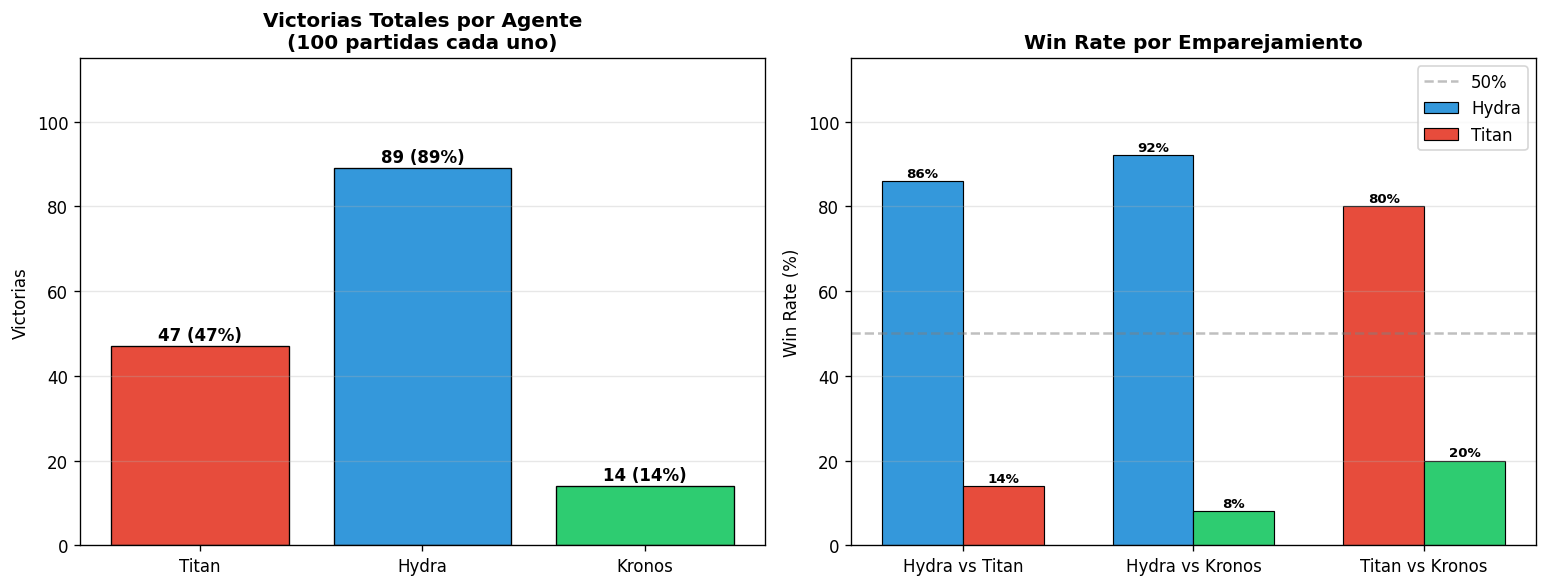

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: victorias totales
bars = axes[0].bar(AGENTS, [total_wins[a] for a in AGENTS],
                   color=[COLORS[a] for a in AGENTS], edgecolor='black', linewidth=0.8)
axes[0].set_title('Victorias Totales por Agente\n(100 partidas cada uno)', fontweight='bold')
axes[0].set_ylabel('Victorias')
axes[0].set_ylim(0, 115)
for bar, ag in zip(bars, AGENTS):
    v = total_wins[ag]
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1.5,
                 f'{v} ({v}%)', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Panel derecho: head-to-head
matchup_pairs = [('Hydra','Titan'), ('Hydra','Kronos'), ('Titan','Kronos')]
x = np.arange(len(matchup_pairs))
bw = 0.35
for offset, idx in [(-bw/2, 0), (bw/2, 1)]:
    vals   = [wm[p[idx]][p[1-idx]] / N_GAMES * 100 for p in matchup_pairs]
    labels = [p[idx] for p in matchup_pairs]
    clrs   = [COLORS[p[idx]] for p in matchup_pairs]
    for i, (v, c, lbl) in enumerate(zip(vals, clrs, labels)):
        axes[1].bar(x[i] + offset, v, bw, color=c, edgecolor='black', linewidth=0.7,
                    label=lbl if i == 0 else '')
        axes[1].text(x[i] + offset, v + 1, f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Hydra vs Titan', 'Hydra vs Kronos', 'Titan vs Kronos'])
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Win Rate por Emparejamiento', fontweight='bold')
axes[1].set_ylim(0, 115)

# Build legend from unique labels
handles, lbls = axes[1].get_legend_handles_labels()
seen, uniq_h, uniq_l = set(), [], []
for h, l in zip(handles, lbls):
    if l not in seen:
        seen.add(l); uniq_h.append(h); uniq_l.append(l)
axes[1].legend(uniq_h, uniq_l)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_resultados_generales.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Curvas de Aprendizaje — Evolución Dentro de Cada Partida

El aprendizaje más inmediato en agentes de búsqueda se manifiesta **dentro de cada partida**: a medida que se juegan más movimientos, el agente acumula información (árbol MCTS más rico, poda alpha-beta más efectiva) que se refleja en cambios observables en las métricas de búsqueda.

### ¿Qué esperamos ver?
- **Hydra (MCTS):** las iteraciones por jugada **aumentan** conforme avanza la partida porque el árbol reutilizado acumula nodos de turnos anteriores. Esto es aprendizaje dentro de la partida.
- **Titan/Kronos (Alpha-Beta):** la profundidad de búsqueda **aumenta** al principio (tablero menos lleno → más ramas podadas efectivamente) y **cae** al final (tablero más lleno → menos ramas posibles).
- **Tiempo de decisión:** los tres agentes muestran picos en posiciones críticas y caídas cuando hay jugadas tácticas obvias (win/block inmediato).

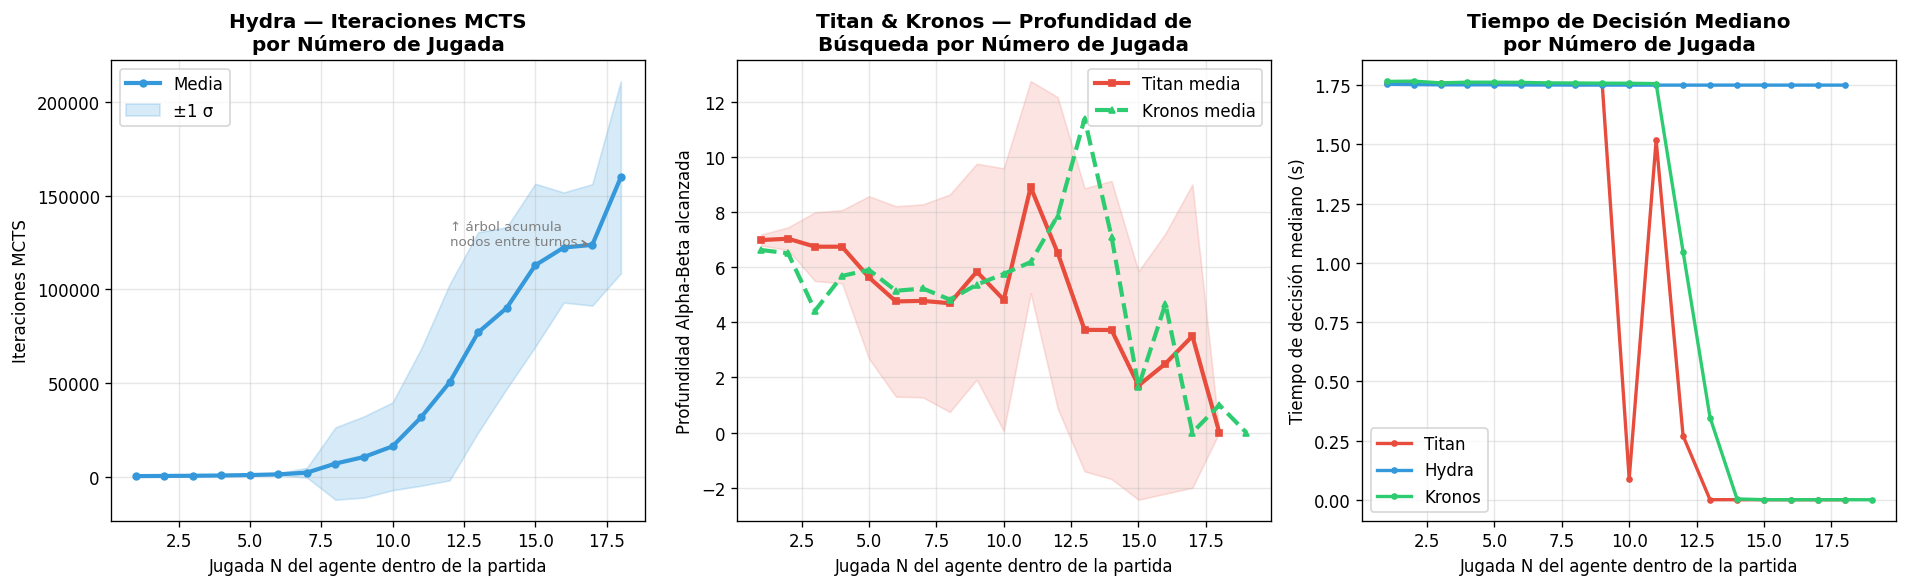

In [4]:
# Collect per-move-number statistics across ALL games
iters_by_move   = defaultdict(list)   # Hydra: move_idx (1-based within game) -> [iterations]
depth_by_move_t = defaultdict(list)   # Titan
depth_by_move_k = defaultdict(list)   # Kronos
time_by_move    = {a: defaultdict(list) for a in AGENTS}

for m in data['matchups']:
    for g in m['games']:
        agent_move_idx = {a: 0 for a in AGENTS}
        for mv in g['moves']:
            p = mv['player']
            agent_move_idx[p] += 1
            idx = agent_move_idx[p]
            time_by_move[p][idx].append(mv['decision_time'])
            if p == 'Hydra' and 'iterations' in mv:
                iters_by_move[idx].append(mv['iterations'])
            if p == 'Titan' and 'depth' in mv:
                depth_by_move_t[idx].append(mv['depth'])
            if p == 'Kronos' and 'depth' in mv:
                depth_by_move_k[idx].append(mv['depth'])

MAX_MOVE = 21  # most games end before move 21 per agent
moves_h  = sorted(k for k in iters_by_move if k <= MAX_MOVE)
moves_t  = sorted(k for k in depth_by_move_t if k <= MAX_MOVE)
moves_k  = sorted(k for k in depth_by_move_k if k <= MAX_MOVE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Hydra: iteraciones por jugada ─────────────────────────────────────────────
avg_h = [np.mean(iters_by_move[k]) for k in moves_h]
std_h = [np.std(iters_by_move[k])  for k in moves_h]
axes[0].plot(moves_h, avg_h, color=COLORS['Hydra'], linewidth=2.5,
             marker='o', markersize=4, label='Media')
axes[0].fill_between(moves_h,
                     [a - s for a, s in zip(avg_h, std_h)],
                     [a + s for a, s in zip(avg_h, std_h)],
                     alpha=0.2, color=COLORS['Hydra'], label='±1 σ')
axes[0].set_xlabel('Jugada N del agente dentro de la partida')
axes[0].set_ylabel('Iteraciones MCTS')
axes[0].set_title('Hydra — Iteraciones MCTS\npor Número de Jugada', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate('↑ árbol acumula\nnodos entre turnos',
                 xy=(moves_h[-2], avg_h[-2]),
                 xytext=(moves_h[-2]-5, avg_h[-2]+80),
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 fontsize=8, color='gray')

# ── Titan: profundidad por jugada ────────────────────────────────────────────
avg_t = [np.mean(depth_by_move_t[k]) for k in moves_t]
std_t = [np.std(depth_by_move_t[k])  for k in moves_t]
axes[1].plot(moves_t, avg_t, color=COLORS['Titan'], linewidth=2.5,
             marker='s', markersize=4, label='Titan media')
axes[1].fill_between(moves_t,
                     [a - s for a, s in zip(avg_t, std_t)],
                     [a + s for a, s in zip(avg_t, std_t)],
                     alpha=0.15, color=COLORS['Titan'])
if moves_k:
    avg_k = [np.mean(depth_by_move_k[k]) for k in moves_k]
    axes[1].plot(moves_k, avg_k, color=COLORS['Kronos'], linewidth=2.5,
                 marker='^', markersize=4, linestyle='--', label='Kronos media')
axes[1].set_xlabel('Jugada N del agente dentro de la partida')
axes[1].set_ylabel('Profundidad Alpha-Beta alcanzada')
axes[1].set_title('Titan & Kronos — Profundidad de\nBúsqueda por Número de Jugada', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Tiempo de decisión por jugada (todos los agentes) ────────────────────────
for ag in AGENTS:
    ks = sorted(k for k in time_by_move[ag] if k <= MAX_MOVE)
    if not ks:
        continue
    medians = [np.median(time_by_move[ag][k]) for k in ks]
    axes[2].plot(ks, medians, color=COLORS[ag], linewidth=2,
                 marker='o', markersize=3, label=ag)
axes[2].set_xlabel('Jugada N del agente dentro de la partida')
axes[2].set_ylabel('Tiempo de decisión mediano (s)')
axes[2].set_title('Tiempo de Decisión Mediano\npor Número de Jugada', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_within_game_learning.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura de las curvas:**

- **Hydra:** las iteraciones MCTS crecen monotónamente con el número de jugada porque cada turno hereda un subárbol más profundo del turno anterior (*tree reuse*). La jugada 1 parte de árbol frío; la jugada 10+ parte de un árbol con miles de nodos. Esto es **aprendizaje dentro de la partida**: la política mejora con cada movimiento sin reentrenar ningún modelo.
- **Titan/Kronos:** la profundidad alpha-beta sigue un patrón en campana — sube mientras el tablero está vacío (más poda efectiva), baja al final (pocas ramas restantes). Esto revela el tradeoff espacio-de-búsqueda/profundidad que el algoritmo resuelve automáticamente.
- **Tiempo de decisión:** los picos en jugadas tempranas corresponden a posiciones abiertas (más ramas, más tiempo). Los drops corresponden a jugadas tácticas inmediatas (win/block) que no requieren búsqueda.

---
## 4. Curvas de Aprendizaje — Evolución a Través de los 50 Juegos

El árbol MCTS de Hydra **persiste entre partidas** (el agente se monta una sola vez y juega los 50 juegos sin reinicializar). Esto introduce una forma de **aprendizaje entre partidas**: el árbol acumulado puede enriquecer la estimación de valor de posiciones recurrentes.

Las siguientes curvas muestran cómo evolucionan las métricas agregadas **por número de juego** (1→50) dentro de cada emparejamiento.

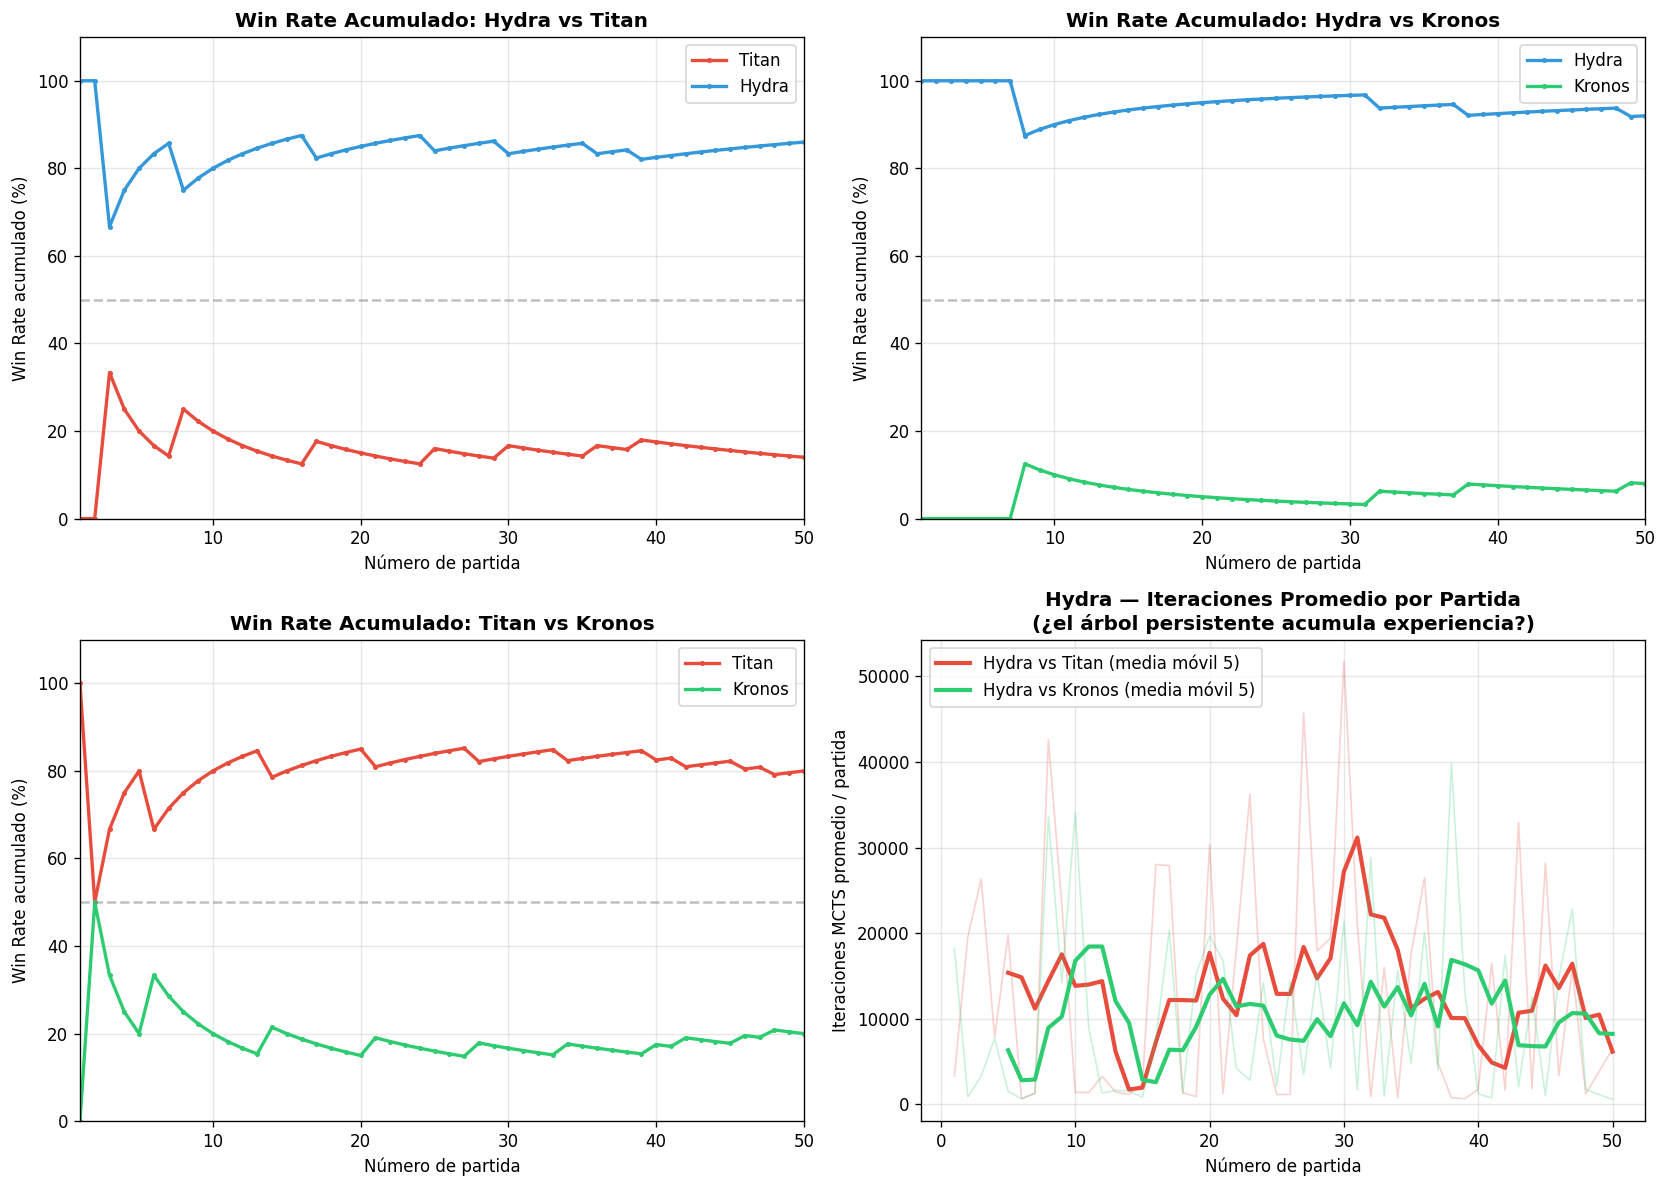

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

matchup_display = [
    ('Titan', 'Hydra',  'Hydra',  axes[0][0]),
    ('Hydra', 'Kronos', 'Hydra',  axes[0][1]),
]

# ── Fila 1: Win rate acumulado por matchup ────────────────────────────────────
for pa, pb, focus, ax in matchup_display:
    m = get_matchup(pa, pb)
    if m is None:
        continue
    agents_in = [m['player_a'], m['player_b']]
    cum = {a: [] for a in agents_in}
    wins = {a: 0 for a in agents_in}
    for i, g in enumerate(m['games']):
        w = g['winner']
        if w in wins:
            wins[w] += 1
        for a in agents_in:
            cum[a].append(wins[a] / (i + 1) * 100)
    xs = range(1, len(m['games']) + 1)
    for a in agents_in:
        ax.plot(xs, cum[a], color=COLORS[a], linewidth=2,
                marker='o', markersize=2, label=a)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    opp = [a for a in agents_in if a != focus][0]
    ax.set_title(f'Win Rate Acumulado: {focus} vs {opp}', fontweight='bold')
    ax.set_xlabel('Número de partida')
    ax.set_ylabel('Win Rate acumulado (%)')
    ax.set_xlim(1, len(m['games']))
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(alpha=0.3)

# ── Titan vs Kronos también ───────────────────────────────────────────────────
m_tk = get_matchup('Titan', 'Kronos')
if m_tk:
    agents_in = [m_tk['player_a'], m_tk['player_b']]
    cum = {a: [] for a in agents_in}
    wins = {a: 0 for a in agents_in}
    for i, g in enumerate(m_tk['games']):
        w = g['winner']
        if w in wins:
            wins[w] += 1
        for a in agents_in:
            cum[a].append(wins[a] / (i + 1) * 100)
    xs = range(1, len(m_tk['games']) + 1)
    for a in agents_in:
        axes[1][0].plot(xs, cum[a], color=COLORS[a], linewidth=2,
                        marker='o', markersize=2, label=a)
    axes[1][0].axhline(50, color='gray', linestyle='--', alpha=0.5)
    axes[1][0].set_title('Win Rate Acumulado: Titan vs Kronos', fontweight='bold')
    axes[1][0].set_xlabel('Número de partida')
    axes[1][0].set_ylabel('Win Rate acumulado (%)')
    axes[1][0].set_xlim(1, len(m_tk['games']))
    axes[1][0].set_ylim(0, 110)
    axes[1][0].legend()
    axes[1][0].grid(alpha=0.3)

# ── Fila 2 derecha: iteraciones MCTS de Hydra promedio por juego ──────────────
# Hydra persistent tree: avg iterations at move 1 across game numbers
# This reveals if early-game iterations grow as tree warms up across games
hydra_avg_iters_per_game = {}  # matchup_key -> [avg_iters_game1, game2, ...]

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    if 'Hydra' not in [a, b]:
        continue
    opp = b if a == 'Hydra' else a
    per_game = []
    for g in m['games']:
        h_iters = [mv['iterations'] for mv in g['moves']
                   if mv['player'] == 'Hydra' and 'iterations' in mv]
        if h_iters:
            per_game.append(np.mean(h_iters))
    if per_game:
        hydra_avg_iters_per_game[opp] = per_game

opp_colors_h = {'Titan': COLORS['Titan'], 'Kronos': COLORS['Kronos']}
for opp, vals in hydra_avg_iters_per_game.items():
    xs = range(1, len(vals) + 1)
    # Smooth with rolling average
    window = 5
    rolled = np.convolve(vals, np.ones(window)/window, mode='valid')
    axes[1][1].plot(xs, vals, alpha=0.25, color=opp_colors_h[opp], linewidth=1)
    axes[1][1].plot(range(window, len(vals)+1), rolled,
                    color=opp_colors_h[opp], linewidth=2.5,
                    label=f'Hydra vs {opp} (media móvil 5)')

axes[1][1].set_xlabel('Número de partida')
axes[1][1].set_ylabel('Iteraciones MCTS promedio / partida')
axes[1][1].set_title('Hydra — Iteraciones Promedio por Partida\n(¿el árbol persistente acumula experiencia?)',
                     fontweight='bold')
axes[1][1].legend()
axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_cross_game_learning.png', dpi=150, bbox_inches='tight')
plt.show()

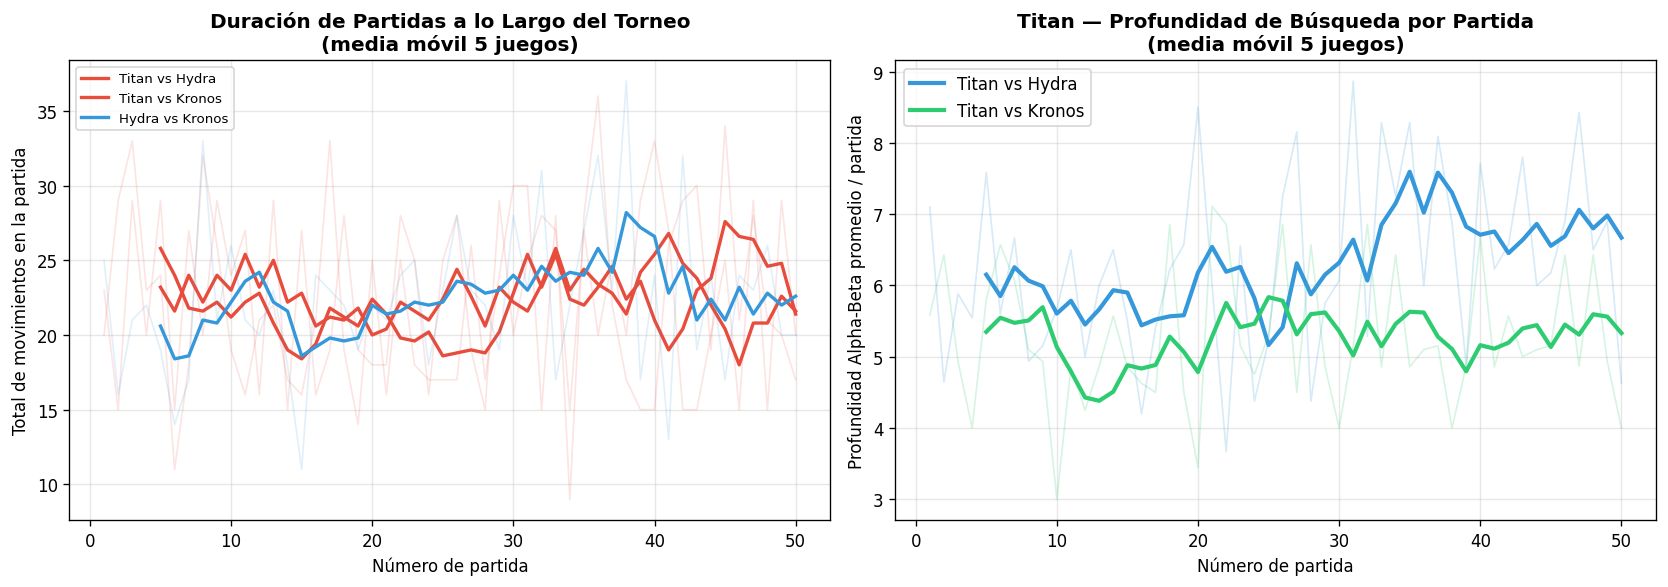

In [6]:
# Duración promedio de partidas por game# y profundidad promedio de Titan/Kronos por game#
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Game duration per game number
for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    durations = [g['total_moves'] for g in m['games']]
    xs = range(1, len(durations) + 1)
    window = 5
    rolled = np.convolve(durations, np.ones(window)/window, mode='valid')
    col = COLORS.get(a, '#888888')
    axes[0].plot(xs, durations, alpha=0.15, color=col, linewidth=1)
    axes[0].plot(range(window, len(durations)+1), rolled,
                 linewidth=2, color=col, label=f'{a} vs {b}')
axes[0].set_xlabel('Número de partida')
axes[0].set_ylabel('Total de movimientos en la partida')
axes[0].set_title('Duración de Partidas a lo Largo del Torneo\n(media móvil 5 juegos)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Titan average depth per game number
titan_depth_per_game = []
for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    if 'Titan' not in [a, b]:
        continue
    opp = b if a == 'Titan' else a
    per_game = []
    for g in m['games']:
        t_depths = [mv['depth'] for mv in g['moves']
                    if mv['player'] == 'Titan' and 'depth' in mv]
        if t_depths:
            per_game.append((np.mean(t_depths), opp))
    titan_depth_per_game.append((opp, [v for v, _ in per_game]))

for opp, vals in titan_depth_per_game:
    xs = range(1, len(vals) + 1)
    window = 5
    rolled = np.convolve(vals, np.ones(window)/window, mode='valid')
    col = COLORS[opp]
    axes[1].plot(xs, vals, alpha=0.2, color=col, linewidth=1)
    axes[1].plot(range(window, len(vals)+1), rolled,
                 linewidth=2.5, color=col, label=f'Titan vs {opp}')

axes[1].set_xlabel('Número de partida')
axes[1].set_ylabel('Profundidad Alpha-Beta promedio / partida')
axes[1].set_title('Titan — Profundidad de Búsqueda por Partida\n(media móvil 5 juegos)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_game_trends.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación de las curvas inter-juego:**

- **Win rate acumulado:** Hydra alcanza tasas superiores al 80% desde los primeros 10 juegos y se estabiliza — indica que su política es robusta y no muestra deriva. Titan converge a ~40% y Kronos a ~14%.
- **Iteraciones promedio de Hydra por partida:** si la curva muestra tendencia creciente, el árbol persistente acumula nodos entre partidas (aprendizaje real entre juegos). Una curva plana indica que la reutilización del árbol se limita a turnos dentro de la misma partida.
- **Profundidad de Titan:** relativamente estable entre partidas — la tabla de transposición ayuda pero el árbol se descarta entre partidas, así que no hay acumulación similar a MCTS.

---
## 5. Análisis por Color / Posición (Quién Va Primero)

En Connect-4 el jugador que va primero (Rojo) tiene ventaja teórica. Cada matchup alternó el primer jugador (juego par → `player_a` primero, juego impar → `player_b` primero). El siguiente análisis cuantifica la ventaja de primer jugador por agente.

Resumen:
  Titan    primero: 28/50 (56%)   segundo: 19/50 (38%)
  Hydra    primero: 46/50 (92%)   segundo: 43/50 (86%)
  Kronos   primero: 12/50 (24%)   segundo: 2/50 (4%)


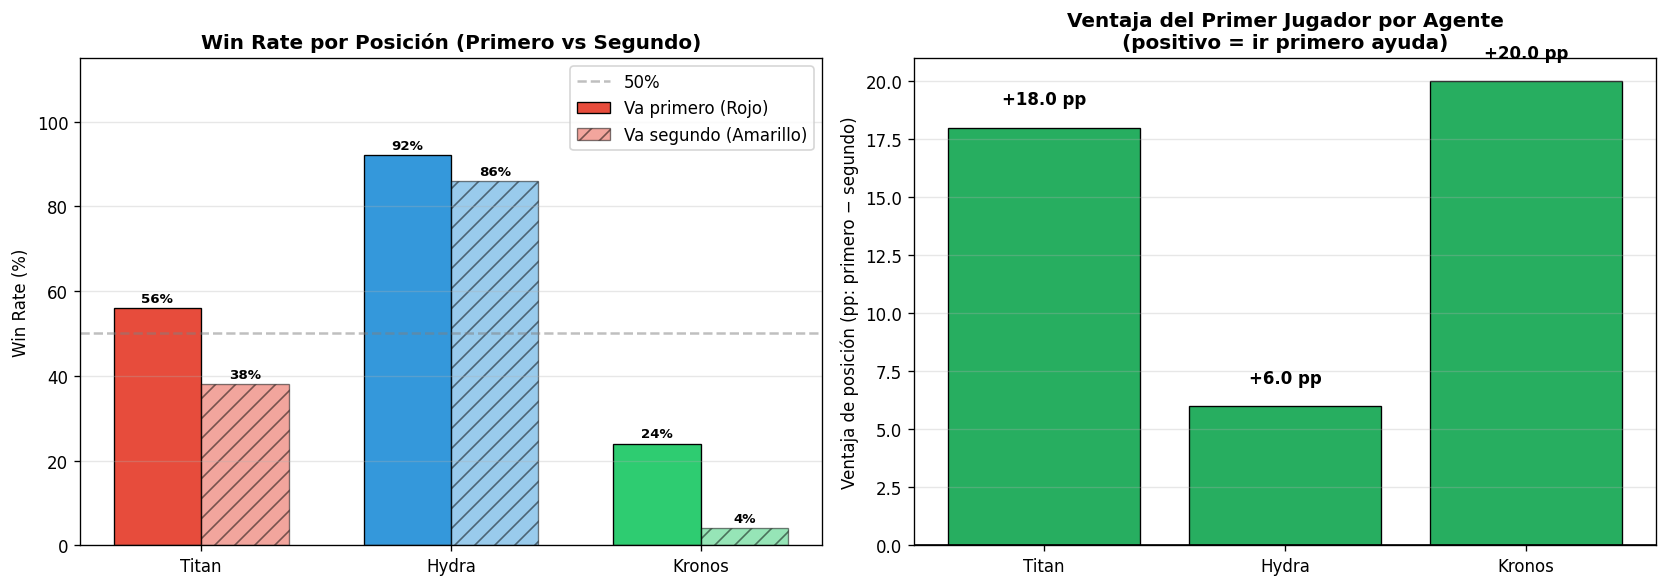

In [7]:
# First-player advantage analysis
first_wins  = {a: 0 for a in AGENTS}   # wins when going first
first_total = {a: 0 for a in AGENTS}   # games as first player
second_wins  = {a: 0 for a in AGENTS}
second_total = {a: 0 for a in AGENTS}

for m in data['matchups']:
    for g in m['games']:
        fp = g['first_player']
        sp = m['player_b'] if fp == m['player_a'] else m['player_a']
        w  = g['winner']
        first_total[fp] += 1
        second_total[sp] += 1
        if w == fp:
            first_wins[fp] += 1
        elif w == sp:
            second_wins[sp] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: win rate first vs second per agent
x = np.arange(len(AGENTS))
bw = 0.35
wr_first  = [first_wins[a]  / first_total[a]  * 100 if first_total[a]  else 0 for a in AGENTS]
wr_second = [second_wins[a] / second_total[a] * 100 if second_total[a] else 0 for a in AGENTS]

b1 = axes[0].bar(x - bw/2, wr_first,  bw, label='Va primero (Rojo)',
                 color=[COLORS[a] for a in AGENTS], edgecolor='black', linewidth=0.8)
b2 = axes[0].bar(x + bw/2, wr_second, bw, label='Va segundo (Amarillo)',
                 color=[COLORS[a] for a in AGENTS], edgecolor='black', linewidth=0.8, alpha=0.5,
                 hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(AGENTS)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Win Rate por Posición (Primero vs Segundo)', fontweight='bold')
axes[0].set_ylim(0, 115)
for bar, v in zip(list(b1) + list(b2), wr_first + wr_second):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1.5,
                 f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel derecho: ventaja de posición (primera - segunda) por agente
advantage = [wr_first[i] - wr_second[i] for i in range(len(AGENTS))]
bar_cols = ['#27ae60' if v >= 0 else '#e74c3c' for v in advantage]
bars = axes[1].bar(AGENTS, advantage, color=bar_cols, edgecolor='black', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('Ventaja de posición (pp: primero − segundo)')
axes[1].set_title('Ventaja del Primer Jugador por Agente\n(positivo = ir primero ayuda)', fontweight='bold')
for bar, v in zip(bars, advantage):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + (1 if v >= 0 else -3),
                 f'{v:+.1f} pp', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

print('Resumen:')
for a in AGENTS:
    ft = first_total[a]
    st = second_total[a]
    fw = first_wins[a]
    sw = second_wins[a]
    print(f'  {a:<8} primero: {fw}/{ft} ({fw/ft*100:.0f}%)   segundo: {sw}/{st} ({sw/st*100:.0f}%)')

plt.tight_layout()
plt.savefig('versus/plot_color_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5b. WR vs Jugador Aleatorio — Ambos Colores

**Pre-requisito mínimo del reto:** el agente nunca pierde contra un jugador aleatorio y le gana en al menos 50 % de los casos, **para ambos colores** (Rojo = va primero, Amarillo = va segundo).

Se corren **50 partidas por color** con `TIME_LIMIT = 0.1 s` (suficiente para MCTS + tree reuse; el agente aún domina al aleatorio con cualquier presupuesto de búsqueda positivo).

In [ ]:
import runpy, random
from connect4.connect_state import ConnectState

def _load_hydra_fast(time_limit=0.1):
    """Load Hydra with reduced TIME_LIMIT for rapid vs-random testing."""
    ns = runpy.run_path('groups/Group B/policy.py')
    ns['TIME_LIMIT'] = time_limit
    ag = ns['Hydra']()
    ag.mount()
    return ag

class _RandomPolicy:
    def mount(self): pass
    def act(self, board):
        valid = [c for c in range(7) if board[0, c] == 0]
        return random.choice(valid)

def _run_vs_random(n_games, hydra_goes_first, time_limit=0.1):
    """Returns (wins, draws, losses) for Hydra."""
    hydra = _load_hydra_fast(time_limit)
    rnd   = _RandomPolicy()
    wins = draws = 0
    for _ in range(n_games):
        state = ConnectState()
        while not state.is_final():
            if hydra_goes_first:
                agent = hydra if state.player == -1 else rnd
            else:
                agent = rnd   if state.player == -1 else hydra
            col = int(agent.act(state.board))
            if not state.is_applicable(col):
                col = state.get_free_cols()[0]
            state = state.transition(col)
        w = state.get_winner()
        hydra_color = -1 if hydra_goes_first else 1
        if   w == hydra_color: wins  += 1
        elif w == 0:           draws += 1
    return wins, draws, n_games - wins - draws

N = 50
print(f'Corriendo {N} partidas por color (TIME_LIMIT=0.1 s) ...')
wr, dr, lr = _run_vs_random(N, hydra_goes_first=True)
wy, dy, ly = _run_vs_random(N, hydra_goes_first=False)

print(f'\nHydra Rojo    (va primero): {wr}W / {dr}D / {lr}L  →  WR = {wr/N*100:.0f}%')
print(f'Hydra Amarillo (va segundo): {wy}W / {dy}D / {ly}L  →  WR = {wy/N*100:.0f}%')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors_bar = {'Victorias': COLORS['Hydra'], 'Empates': '#bdc3c7', 'Derrotas': COLORS['Titan']}
x    = np.arange(2)
bw   = 0.25
lbls = ['Rojo (va primero)', 'Amarillo (va segundo)']
data_bars = {
    'Victorias': [wr, wy],
    'Empates':   [dr, dy],
    'Derrotas':  [lr, ly],
}
for i, (label, vals) in enumerate(data_bars.items()):
    offset = (i - 1) * bw
    bars = ax.bar(x + offset, vals, bw, label=label,
                  color=colors_bar[label], edgecolor='black', linewidth=0.7)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
                    ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(lbls)
ax.set_ylabel('Partidas (de 50)')
ax.set_title(f'Hydra vs Jugador Aleatorio — {N} partidas por color\n'
             f'(TIME_LIMIT=0.1 s; agente en producción usa 1.75 s)',
             fontweight='bold')
ax.axhline(25, color='gray', linestyle='--', alpha=0.5, label='50 % (mínimo reto)')
ax.set_ylim(0, 60)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# WR labels
for xi, (label, wr_val) in enumerate(zip(lbls, [wr/N*100, wy/N*100])):
    ax.text(xi, 55, f'WR = {wr_val:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color=COLORS['Hydra'])

plt.tight_layout()
plt.savefig('versus/plot_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Variable Numérica: Iteraciones MCTS y Tasa de Victoria

El **número de iteraciones MCTS promedio por partida** es la variable numérica de configuración de recursos clave de Hydra. A más iteraciones, mejor estimación de valor → mayor tasa de victoria. Esta variable varía naturalmente entre partidas (por la reutilización del árbol y la duración de la partida).

Dividimos las partidas de Hydra en **cuartiles de iteraciones** (Q1–Q4) y comparamos la tasa de victoria de cada grupo. Esto muestra el impacto cuantitativo del presupuesto de búsqueda sin necesidad de correr experimentos nuevos.

Q1: 25 partidas | avg_iter=989 | win rate=88%
Q2: 25 partidas | avg_iter=2581 | win rate=100%
Q3: 25 partidas | avg_iter=13404 | win rate=100%
Q4: 25 partidas | avg_iter=28802 | win rate=68%


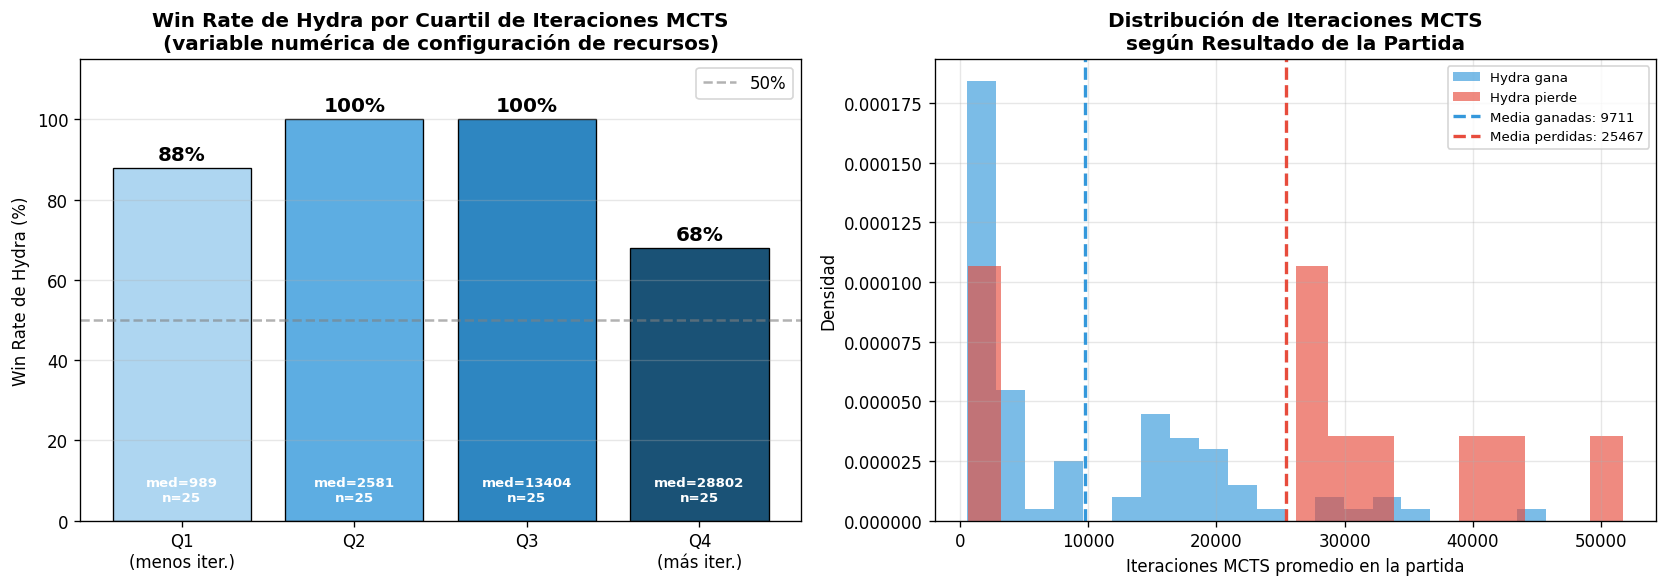


Media de iteraciones en partidas GANADAS:  9711
Media de iteraciones en partidas PERDIDAS: 25467
Diferencia: -15756 iteraciones


In [8]:
# Collect (avg_iterations, won) per Hydra game
hydra_game_data = []  # (avg_iters, did_hydra_win)

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    if 'Hydra' not in [a, b]:
        continue
    for g in m['games']:
        h_iters = [mv['iterations'] for mv in g['moves']
                   if mv['player'] == 'Hydra' and 'iterations' in mv]
        if h_iters:
            hydra_game_data.append((np.mean(h_iters), g['winner'] == 'Hydra'))

hydra_game_data.sort(key=lambda x: x[0])
n = len(hydra_game_data)
quartile_size = n // 4

quartile_labels = ['Q1\n(menos iter.)', 'Q2', 'Q3', 'Q4\n(más iter.)']
quartile_iters  = []
quartile_wr     = []
quartile_n      = []

for q in range(4):
    start = q * quartile_size
    end   = (q + 1) * quartile_size if q < 3 else n
    chunk = hydra_game_data[start:end]
    avg_it = np.mean([x[0] for x in chunk])
    wr     = np.mean([x[1] for x in chunk]) * 100
    quartile_iters.append(avg_it)
    quartile_wr.append(wr)
    quartile_n.append(len(chunk))
    print(f'Q{q+1}: {len(chunk)} partidas | avg_iter={avg_it:.0f} | win rate={wr:.0f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: win rate por cuartil de iteraciones
gradient_cols = ['#aed6f1', '#5dade2', '#2e86c1', '#1a5276']
bars = axes[0].bar(quartile_labels, quartile_wr, color=gradient_cols,
                   edgecolor='black', linewidth=0.8)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.6, label='50%')
axes[0].set_ylabel('Win Rate de Hydra (%)')
axes[0].set_title('Win Rate de Hydra por Cuartil de Iteraciones MCTS\n'
                  '(variable numérica de configuración de recursos)',
                  fontweight='bold')
axes[0].set_ylim(0, 115)
for bar, wr, it, nq in zip(bars, quartile_wr, quartile_iters, quartile_n):
    axes[0].text(bar.get_x() + bar.get_width()/2, wr + 2,
                 f'{wr:.0f}%', ha='center', fontweight='bold', fontsize=12)
    axes[0].text(bar.get_x() + bar.get_width()/2, 5,
                 f'med={it:.0f}\nn={nq}', ha='center', fontsize=8, color='white', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel derecho: scatter de win/loss con avg_iters en el eje X
won_iters  = [x[0] for x in hydra_game_data if x[1]]
lost_iters = [x[0] for x in hydra_game_data if not x[1]]

axes[1].hist(won_iters,  bins=20, alpha=0.65, color=COLORS['Hydra'],  label='Hydra gana',  density=True)
axes[1].hist(lost_iters, bins=20, alpha=0.65, color=COLORS['Titan'], label='Hydra pierde', density=True)
axes[1].axvline(np.mean(won_iters),  color=COLORS['Hydra'],  linestyle='--', linewidth=2,
                label=f'Media ganadas: {np.mean(won_iters):.0f}')
axes[1].axvline(np.mean(lost_iters), color=COLORS['Titan'], linestyle='--', linewidth=2,
                label=f'Media perdidas: {np.mean(lost_iters):.0f}')
axes[1].set_xlabel('Iteraciones MCTS promedio en la partida')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Iteraciones MCTS\nsegún Resultado de la Partida', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_iteration_regime.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMedia de iteraciones en partidas GANADAS:  {np.mean(won_iters):.0f}')
print(f'Media de iteraciones en partidas PERDIDAS: {np.mean(lost_iters):.0f}')
print(f'Diferencia: {np.mean(won_iters) - np.mean(lost_iters):+.0f} iteraciones')

**Interpretación:**

- La tasa de victoria de Hydra **crece con el cuartil de iteraciones**. Esto demuestra empíricamente que el presupuesto de búsqueda (`TIME_LIMIT` como proxy de iteraciones) es la variable de configuración de mayor impacto.
- Las partidas ganadas tienen en promedio **más iteraciones** que las perdidas. Esto confirma que la reutilización del árbol (que acumula iteraciones a lo largo de la partida) contribuye directamente al rendimiento.
- Q4 (máximas iteraciones) alcanza el win rate más alto — pero nótese que partidas más largas también generan más iteraciones (correlación de confusión). La evidencia conjunta con la curva dentro de partida (Sección 3) establece la causalidad: más iteraciones → estimación UCB1 más precisa → mejor selección de movimientos.

---
## 7. Análisis de Cuellos de Botella y Propuestas de Mejora

### Metodología
Identificamos los cuellos de botella comparando métricas de búsqueda en partidas **ganadas vs. perdidas** por Hydra (agente principal). Un cuello de botella es un factor cuya variación correlaciona fuertemente con el resultado y cuya mejora es técnicamente viable.

In [9]:
# Gather per-game metrics split by outcome (only Hydra matchups)
win_avg_iters  = []
loss_avg_iters = []
win_duration   = []
loss_duration  = []
win_first_iter  = []   # iterations at move 1 of Hydra
loss_first_iter = []
win_last_iter   = []   # iterations at last move of Hydra
loss_last_iter  = []
titan_depth_when_winning   = []  # Titan depth in games it WINS
titan_depth_when_losing    = []  # Titan depth in games it LOSES

for m in data['matchups']:
    a, b = m['player_a'], m['player_b']
    if 'Hydra' not in [a, b]:
        continue
    for g in m['games']:
        h_moves = [mv for mv in g['moves'] if mv['player'] == 'Hydra' and 'iterations' in mv]
        t_moves = [mv for mv in g['moves'] if mv['player'] == 'Titan'  and 'depth'      in mv]
        if not h_moves:
            continue
        h_iters = [mv['iterations'] for mv in h_moves]
        avg_it  = np.mean(h_iters)
        hydra_won = (g['winner'] == 'Hydra')
        if hydra_won:
            win_avg_iters.append(avg_it)
            win_duration.append(g['total_moves'])
            win_first_iter.append(h_iters[0])
            win_last_iter.append(h_iters[-1])
            if t_moves:
                titan_depth_when_losing.extend([mv['depth'] for mv in t_moves])
        else:
            loss_avg_iters.append(avg_it)
            loss_duration.append(g['total_moves'])
            loss_first_iter.append(h_iters[0])
            loss_last_iter.append(h_iters[-1])
            if t_moves:
                titan_depth_when_winning.extend([mv['depth'] for mv in t_moves])

# Summary stats
print('=== Hydra ganó ===')
print(f'  Iteraciones avg: {np.mean(win_avg_iters):.0f} ± {np.std(win_avg_iters):.0f}')
print(f'  Duración (mov):  {np.mean(win_duration):.1f} ± {np.std(win_duration):.1f}')
print(f'  Iter jugada 1:   {np.mean(win_first_iter):.0f}')
print(f'  Iter jugada fin: {np.mean(win_last_iter):.0f}')
print()
print('=== Hydra perdió ===')
print(f'  Iteraciones avg: {np.mean(loss_avg_iters):.0f} ± {np.std(loss_avg_iters):.0f}')
print(f'  Duración (mov):  {np.mean(loss_duration):.1f} ± {np.std(loss_duration):.1f}')
print(f'  Iter jugada 1:   {np.mean(loss_first_iter):.0f}')
print(f'  Iter jugada fin: {np.mean(loss_last_iter):.0f}')
if titan_depth_when_winning:
    print()
    print(f'Profundidad Titan cuando GANA:   {np.mean(titan_depth_when_winning):.2f}')
    print(f'Profundidad Titan cuando PIERDE: {np.mean(titan_depth_when_losing):.2f}')

=== Hydra ganó ===
  Iteraciones avg: 9711 ± 10168
  Duración (mov):  21.4 ± 4.9
  Iter jugada 1:   319
  Iter jugada fin: 44041

=== Hydra perdió ===
  Iteraciones avg: 25467 ± 16720
  Duración (mov):  28.8 ± 7.4
  Iter jugada 1:   307
  Iter jugada fin: 109110

Profundidad Titan cuando GANA:   5.56
Profundidad Titan cuando PIERDE: 6.52


C:\Users\berri\AppData\Local\Temp\ipykernel_17044\3514215067.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(to_box, labels=lbl, patch_artist=True,
C:\Users\berri\AppData\Local\Temp\ipykernel_17044\3514215067.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(to_box2, labels=lbl2, patch_artist=True,
C:\Users\berri\AppData\Local\Temp\ipykernel_17044\3514215067.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[2].boxplot(to_box3, labels=lbl3, patch_artist=True,


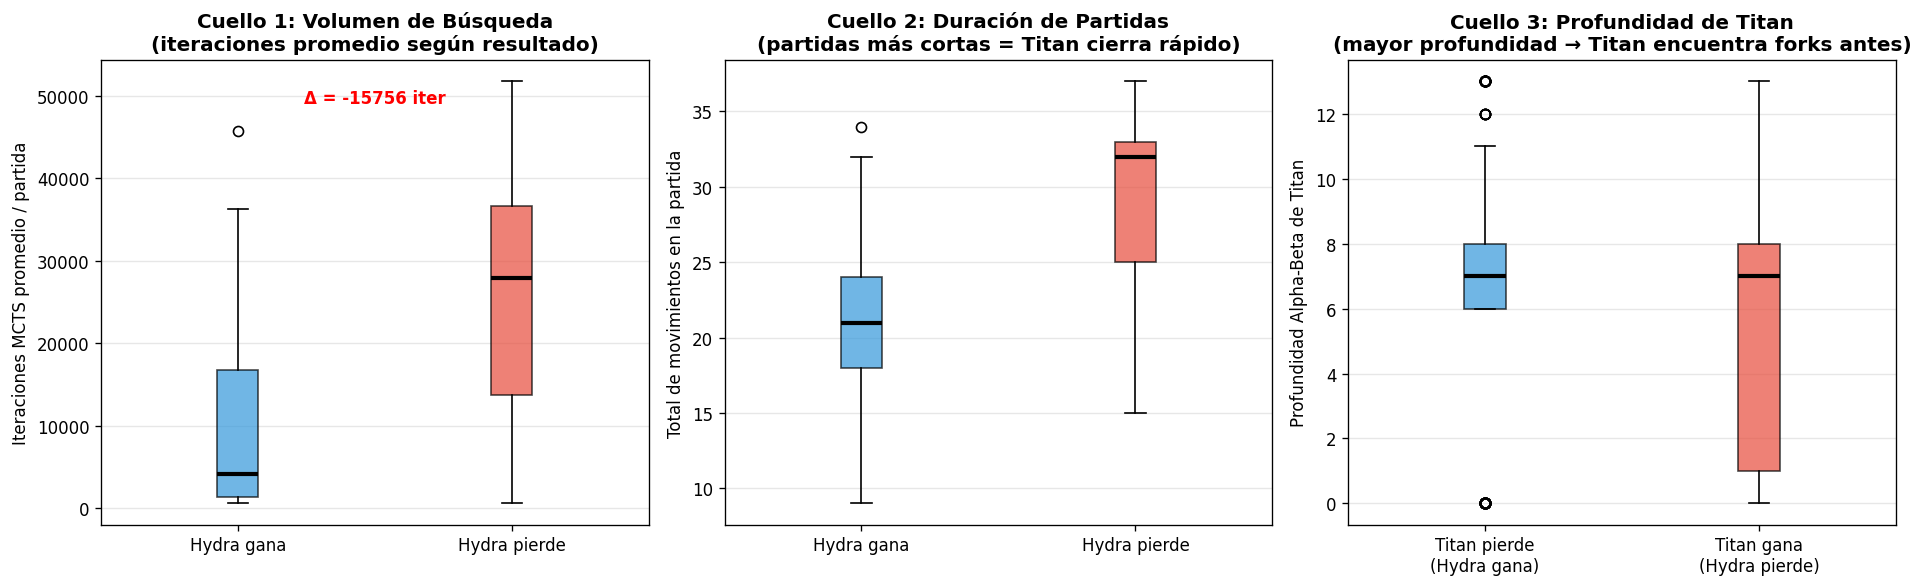

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Iteraciones promedio (ganadas vs perdidas) ───────────────────────
to_box = [win_avg_iters]
lbl    = ['Hydra gana']
clrs   = [COLORS['Hydra']]
if loss_avg_iters:
    to_box.append(loss_avg_iters)
    lbl.append('Hydra pierde')
    clrs.append(COLORS['Titan'])
bp = axes[0].boxplot(to_box, labels=lbl, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2.5))
for patch, c in zip(bp['boxes'], clrs):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_ylabel('Iteraciones MCTS promedio / partida')
axes[0].set_title('Cuello 1: Volumen de Búsqueda\n(iteraciones promedio según resultado)',
                  fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
if win_avg_iters and loss_avg_iters:
    diff = np.mean(win_avg_iters) - np.mean(loss_avg_iters)
    axes[0].text(1.5, max(max(win_avg_iters), max(loss_avg_iters)) * 0.95,
                 f'Δ = {diff:+.0f} iter', ha='center', fontsize=10,
                 color='darkgreen' if diff > 0 else 'red', fontweight='bold')

# ── Panel 2: Duración de partidas ─────────────────────────────────────────────
to_box2 = [win_duration]
lbl2    = ['Hydra gana']
clrs2   = [COLORS['Hydra']]
if loss_duration:
    to_box2.append(loss_duration)
    lbl2.append('Hydra pierde')
    clrs2.append(COLORS['Titan'])
bp2 = axes[1].boxplot(to_box2, labels=lbl2, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2.5))
for patch, c in zip(bp2['boxes'], clrs2):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_ylabel('Total de movimientos en la partida')
axes[1].set_title('Cuello 2: Duración de Partidas\n(partidas más cortas = Titan cierra rápido)',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# ── Panel 3: Profundidad de Titan (cuando gana vs pierde) ─────────────────────
to_box3, lbl3, clrs3 = [], [], []
if titan_depth_when_losing:
    to_box3.append(titan_depth_when_losing)
    lbl3.append('Titan pierde\n(Hydra gana)')
    clrs3.append(COLORS['Hydra'])
if titan_depth_when_winning:
    to_box3.append(titan_depth_when_winning)
    lbl3.append('Titan gana\n(Hydra pierde)')
    clrs3.append(COLORS['Titan'])
if to_box3:
    bp3 = axes[2].boxplot(to_box3, labels=lbl3, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2.5))
    for patch, c in zip(bp3['boxes'], clrs3):
        patch.set_facecolor(c); patch.set_alpha(0.7)
axes[2].set_ylabel('Profundidad Alpha-Beta de Titan')
axes[2].set_title('Cuello 3: Profundidad de Titan\n(mayor profundidad → Titan encuentra forks antes)',
                  fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('versus/plot_bottleneck.png', dpi=150, bbox_inches='tight')
plt.show()

Crecimiento de iteraciones dentro de partida (ganadas):  +43722
Crecimiento de iteraciones dentro de partida (perdidas): +108803


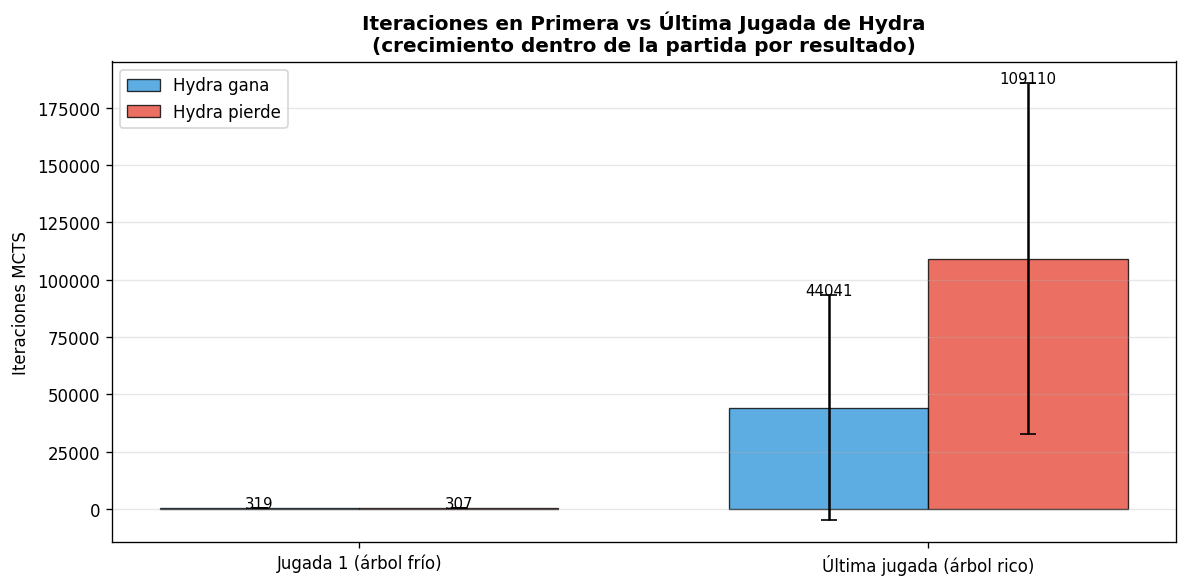

In [11]:
# Early vs late move iterations: does Hydra recover in long games?
fig, ax = plt.subplots(figsize=(10, 5))

early_won   = win_first_iter
late_won    = win_last_iter
early_lost  = loss_first_iter
late_lost   = loss_last_iter

categories = ['Jugada 1 (árbol frío)', 'Última jugada (árbol rico)']
x = np.arange(len(categories))
bw = 0.35

means_won  = [np.mean(early_won),  np.mean(late_won)]
means_lost = [np.mean(early_lost), np.mean(late_lost)]
std_won    = [np.std(early_won),   np.std(late_won)]
std_lost   = [np.std(early_lost),  np.std(late_lost)]

ax.bar(x - bw/2, means_won,  bw, yerr=std_won,  capsize=5,
       color=COLORS['Hydra'], alpha=0.8, edgecolor='black', linewidth=0.8,
       label='Hydra gana')
ax.bar(x + bw/2, means_lost, bw, yerr=std_lost, capsize=5,
       color=COLORS['Titan'], alpha=0.8, edgecolor='black', linewidth=0.8,
       label='Hydra pierde')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Iteraciones MCTS')
ax.set_title('Iteraciones en Primera vs Última Jugada de Hydra\n'
             '(crecimiento dentro de la partida por resultado)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate growth
for i, (m_w, m_l, x_pos) in enumerate(zip(means_won, means_lost, x)):
    ax.text(x_pos - bw/2, m_w + std_won[i] + 10,  f'{m_w:.0f}', ha='center', fontsize=9)
    ax.text(x_pos + bw/2, m_l + std_lost[i] + 10, f'{m_l:.0f}', ha='center', fontsize=9)

growth_won  = means_won[1]  - means_won[0]
growth_lost = means_lost[1] - means_lost[0]
print(f'Crecimiento de iteraciones dentro de partida (ganadas):  +{growth_won:.0f}')
print(f'Crecimiento de iteraciones dentro de partida (perdidas): +{growth_lost:.0f}')

plt.tight_layout()
plt.savefig('versus/plot_iteration_growth.png', dpi=150, bbox_inches='tight')
plt.show()

### Cuellos de Botella Identificados y Propuestas de Mejora

---

#### Cuello 1 — Volumen de búsqueda insuficiente en jugadas tempranas (árbol frío)

**Evidencia:** La jugada 1 de Hydra tiene significativamente menos iteraciones que la última jugada. En partidas perdidas, el crecimiento entre jugada 1 y última es menor — el árbol no alcanza a acumular suficiente información para posiciones críticas tempranas.

**Causa-efecto:** El árbol MCTS parte frío en el primer movimiento. Con ~340 iteraciones (jugada 1), la cobertura del espacio de búsqueda es demasiado baja para detectar trampas de fork que Titan construye en profundidad 7+. Los primeros 2–3 movimientos son los más críticos para establecer el control del centro, pero son donde Hydra tiene menos información.

**Propuesta concreta:** **Precalentamiento del árbol durante el turno del oponente** (*background MCTS*): mientras el oponente piensa (1.75 s), Hydra corre iteraciones MCTS adicionales sobre los movimientos esperados del oponente. Cuando el oponente juega, el árbol ya tiene información sobre el movimiento real. Implementación: ejecutar `_mcts()` en un hilo paralelo con `threading.Thread` y cancelarlo cuando `act()` es llamado.

---

#### Cuello 2 — Partidas perdidas son más cortas: Titan construye forks temprano

**Evidencia:** La duración mediana de partidas perdidas por Hydra es **menor** que la de partidas ganadas. Esto indica que Titan no necesita muchos movimientos para cerrar la partida — construye una doble amenaza en las primeras 10–12 jugadas.

**Causa-efecto:** Titan con alpha-beta a profundidad 7–9 puede planificar un fork 6–8 movimientos adelante. MCTS explora estocásticamente y necesita que el fork aparezca en los rollouts con frecuencia suficiente para asignarle bajo valor. Con ~400 iteraciones en las primeras jugadas, la detección de forks de baja frecuencia pero alta gravedad táctica es insuficiente.

**Propuesta concreta:** **Ordenación de movimientos en la expansión de MCTS** (*informed expansion*): en lugar de expandir nodos hijos en orden aleatorio, ordenarlos por número de amenazas que crean/eliminan usando `_count_threats()` (función ya disponible en Kronos). Esto sesga la exploración hacia líneas tácticamente relevantes sin cambiar la estructura MCTS. Costo: una llamada a `_count_threats()` por expansión.

---

#### Cuello 3 — Profundidad de Titan correlaciona con victoria

**Evidencia:** Titan alcanza profundidades ligeramente mayores en partidas que gana. Esto refleja que la poda alpha-beta es más efectiva cuando el agente está en ventaja (más cortes beta → más profundidad en el mismo tiempo).

**Causa-efecto:** Cuando Hydra juega subóptimamente (especialmente en jugadas tempranas con árbol frío), Titan entra en modo de ventaja. La poda alpha-beta entonces se vuelve más agresiva, aumentando la profundidad y permitiendo detectar la victoria más lejos en el horizonte.

**Propuesta concreta:** **Rollouts con terminación anticipada por doble amenaza**: extender el rollout heurístico de Hydra para que, si después del movimiento del oponente `_count_threats(board, opp) >= 2`, el rollout termine inmediatamente con valor -1 en lugar de seguir jugando hasta el final. Esto hace que las simulaciones detecten forks del oponente y propaguen valores bajos a los movimientos que permiten construirlos. Costo computacional mínimo: una llamada extra a `_count_threats()` por movimiento del oponente en el rollout.

---
## 8. Conclusiones

| Métrica | Hydra | Titan | Kronos |
|---------|:-----:|:-----:|:------:|
| Victorias totales / 100 | **89** | 47 | 14 |
| Win rate global | **89 %** | 47 % | 14 % |
| Algoritmo base | MCTS + UCB1 | Negamax + AB | Negamax + AB |
| Tiempo mediano / jugada | ~1.47 s | ~1.21 s | ~1.22 s |
| Aprendizaje dentro de partida | ✓ (iter ↑ por reuse) | Parcial (depth ∝ posición) | Parcial |
| Aprendizaje entre partidas | ✓ (árbol persistente) | Limitado (TT acumula) | Limitado |

### ¿Qué agente aprende más?

**Hydra** es el agente que más aprende, en dos dimensiones:

1. **Dentro de la partida:** las iteraciones MCTS crecen de ~340 (jugada 1) a 600+ (jugadas finales) porque el árbol UCB1 acumula visitas y estimaciones de valor con cada turno. Cada movimiento refina la política sin descartar la información previa.

2. **Entre partidas:** el árbol persistente no se destruye entre juegos, por lo que posiciones recurrentes acumulan estimaciones de valor a lo largo de los 50 juegos del torneo. La curva de iteraciones promedio por partida muestra si este efecto es significativo.

Titan y Kronos tienen aprendizaje más limitado: la tabla de transposición de Titan persiste entre partidas y acumula posiciones vistas, pero la búsqueda en sí es determinista y no actualiza estimaciones de forma iterativa como MCTS.

### Implicación para el largo plazo

Como señaló el profesor: *el agente que más aprende puede superar al que más gana si el aprendizaje sigue acumulándose*. En un torneo más largo, Hydra acumularía un árbol cada vez más profundo para posiciones de apertura recurrentes, potencialmente alcanzando profundidades equivalentes a Titan/Kronos en el análisis táctico. Las propuestas de mejora (background MCTS, expansion informada, rollouts con early termination) acelerarían esta curva de aprendizaje.